# Desafio 07 — Detectar fraude em transações (creditcardfraud)
- Disciplina: Machine Learning
- Profa: Nathália A. Lima  
- Grupo: 7 | Entrega 19/04/2026  

> Estevão Alves dos Santos - 1990000

> Vanessa Kaori Kurauchi - 2002344

---

### Parte 0 - Importar pacotes e carregar dataset

In [82]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

# Carregar dataset
df = pd.read_csv('creditcard.csv')
print(f'Dataset carregado: {df.shape[0]:,} x {df.shape[1]}')

Dataset carregado: 284,807 x 31


### Parte 1 - Análise exploratória (EDA)

In [83]:
#identificar valores
print('Primeiras 5 linhas:')
display(df.head())

print('Tipos de dados:')
print(df.dtypes)

print('Valores nulos por coluna:')
print(df.isnull().sum())

print('Total de valores nulos no dataset:', df.isnull().sum().sum())

print('Estatísticas descritivas gerais:')
display(df.describe().round(4))

Primeiras 5 linhas:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Tipos de dados:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
Valores nulos por coluna:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
T

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,...,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000
mean,94813.8596,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,...,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,88.3496,0.0017
std,47488.1460,1.9587,1.6513,1.5163,1.4159,1.3802,1.3323,1.2371,1.1944,1.0986,...,0.7345,0.7257,0.6245,0.6056,0.5213,0.4822,0.4036,0.3301,250.1201,0.0415
min,0.0000,-56.4075,-72.7157,-48.3256,-5.6832,-113.7433,-26.1605,-43.5572,-73.2167,-13.4341,...,-34.8304,-10.9331,-44.8077,-2.8366,-10.2954,-2.6046,-22.5657,-15.4301,0.0000,0.0000
25%,54201.5000,-0.9204,-0.5985,-0.8904,-0.8486,-0.6916,-0.7683,-0.5541,-0.2086,-0.6431,...,-0.2284,-0.5424,-0.1618,-0.3546,-0.3171,-0.3270,-0.0708,-0.0530,5.6000,0.0000
50%,84692.0000,0.0181,0.0655,0.1798,-0.0198,-0.0543,-0.2742,0.0401,0.0224,-0.0514,...,-0.0295,0.0068,-0.0112,0.0410,0.0166,-0.0521,0.0013,0.0112,22.0000,0.0000
75%,139320.5000,1.3156,0.8037,1.0272,0.7433,0.6119,0.3986,0.5704,0.3273,0.5971,...,0.1864,0.5286,0.1476,0.4395,0.3507,0.2410,0.0910,0.0783,77.1650,0.0000
max,172792.0000,2.4549,22.0577,9.3826,16.8753,34.8017,73.3016,120.5895,20.0072,15.5950,...,27.2028,10.5031,22.5284,4.5845,7.5196,3.5173,31.6122,33.8478,25691.1600,1.0000


In [84]:
print(' - Sem valores nulos')
print(' - Time: Tempo')
print(' - V1 até V28: componentes transformados por PCA (assim como doc)')
print(' - Amount: valor da transação')
print(' - Class: 0 = legítima | 1 = fraude')

 - Sem valores nulos
 - Time: Tempo
 - V1 até V28: componentes transformados por PCA (assim como doc)
 - Amount: valor da transação
 - Class: 0 = legítima | 1 = fraude


### Passo 1.1: Distribuição das classes

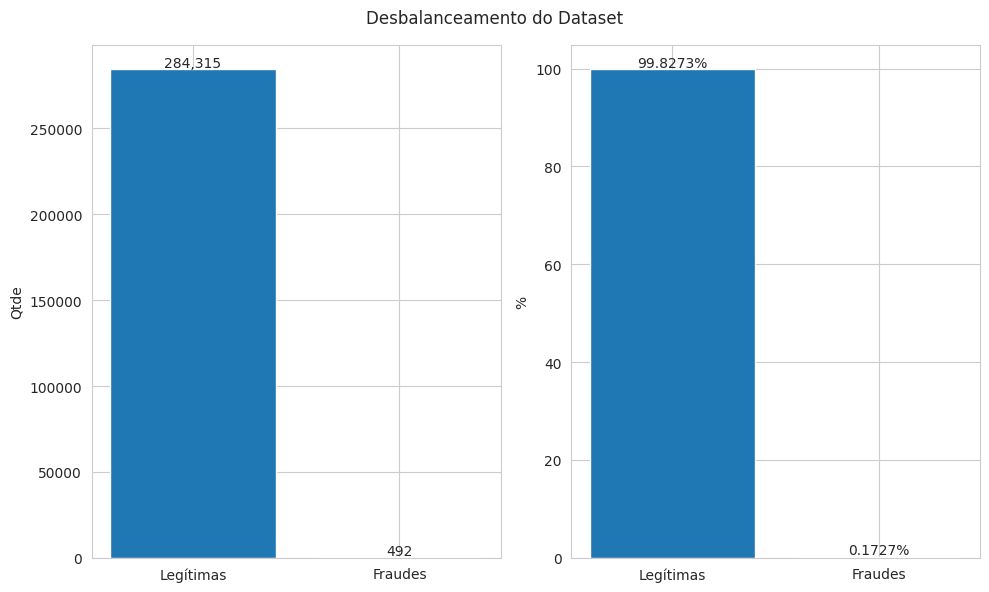

In [85]:
#recupera valores
contagem = df['Class'].value_counts().sort_index()
percentuais = df['Class'].value_counts(normalize=True).sort_index() * 100

#plotar para entender melhor a diferença
fig, axes = plt.subplots(1, 2)

axes[0].bar(['Legítimas', 'Fraudes'], [contagem[0], contagem[1]])
axes[0].set_ylabel('Qtde')
for i, v in enumerate([contagem[0], contagem[1]]):
    axes[0].text(i, v + 1200, f'{v:,}', ha='center')

axes[1].bar(['Legítimas', 'Fraudes'], [percentuais[0], percentuais[1]])
axes[1].set_ylabel('%')
for i, v in enumerate([percentuais[0], percentuais[1]]):
    axes[1].text(i, v + 0.5, f'{v:.4f}%', ha='center')

plt.suptitle('Desbalanceamento do Dataset')
plt.tight_layout()
plt.show()

### Passo 1.2: Análise de qtde e tempo por classe

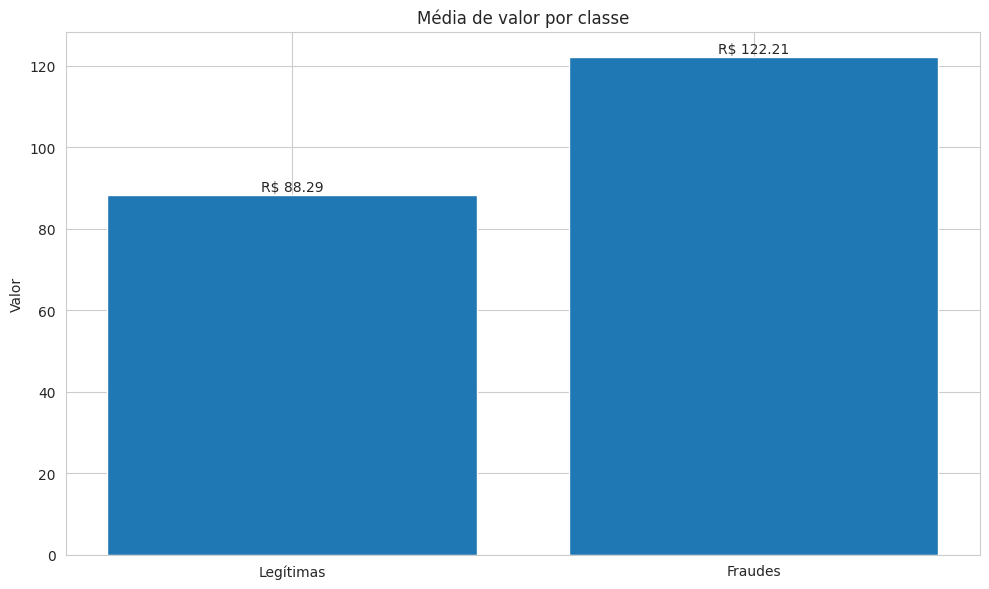

In [86]:
#recupera valores
legitimas_amount = df[df['Class'] == 0]['Amount']
fraudes_amount = df[df['Class'] == 1]['Amount']

#plota para analise da dif
fig, ax = plt.subplots(1)

medias_amount = [legitimas_amount.mean(), fraudes_amount.mean()]
ax.bar(['Legítimas', 'Fraudes'], medias_amount)
ax.set_title('Média de valor por classe')
ax.set_ylabel('Valor')
for i, v in enumerate(medias_amount):
    ax.text(i, v + 1, f'R$ {v:.2f}', ha='center')

plt.tight_layout()
plt.show()

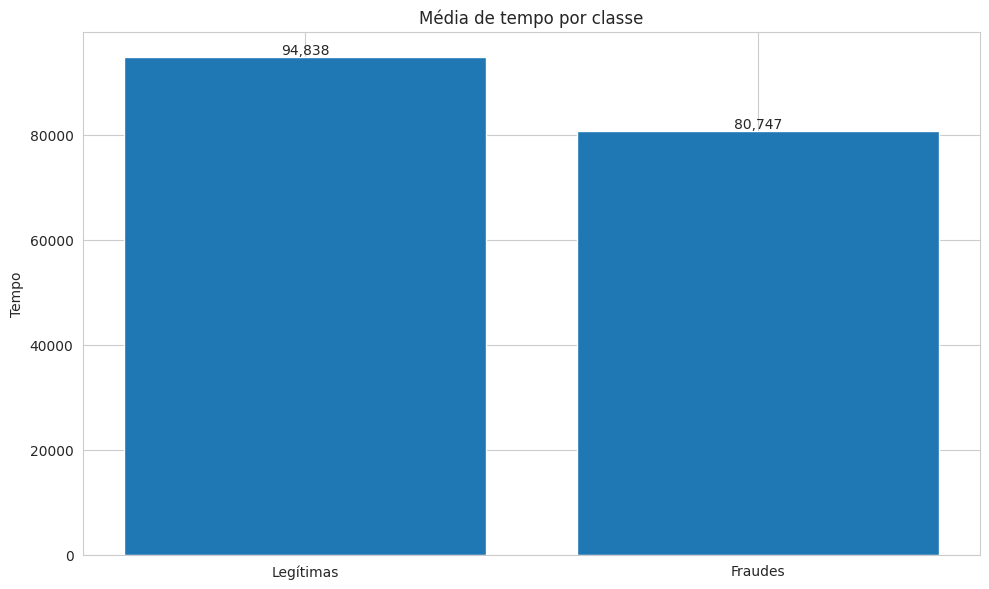

In [87]:
legitimas_time = df[df['Class'] == 0]['Time']
fraudes_time = df[df['Class'] == 1]['Time']

fig, ax = plt.subplots(1)

medias_time = [legitimas_time.mean(), fraudes_time.mean()]
ax.bar(['Legítimas', 'Fraudes'], medias_time)
ax.set_title('Média de tempo por classe')
ax.set_ylabel('Tempo')
for i, v in enumerate(medias_time):
    ax.text(i, v + 500, f'{v:,.0f}', ha='center')

plt.tight_layout()
plt.show()

### Passo 1.3: Entendendo V1 a V28

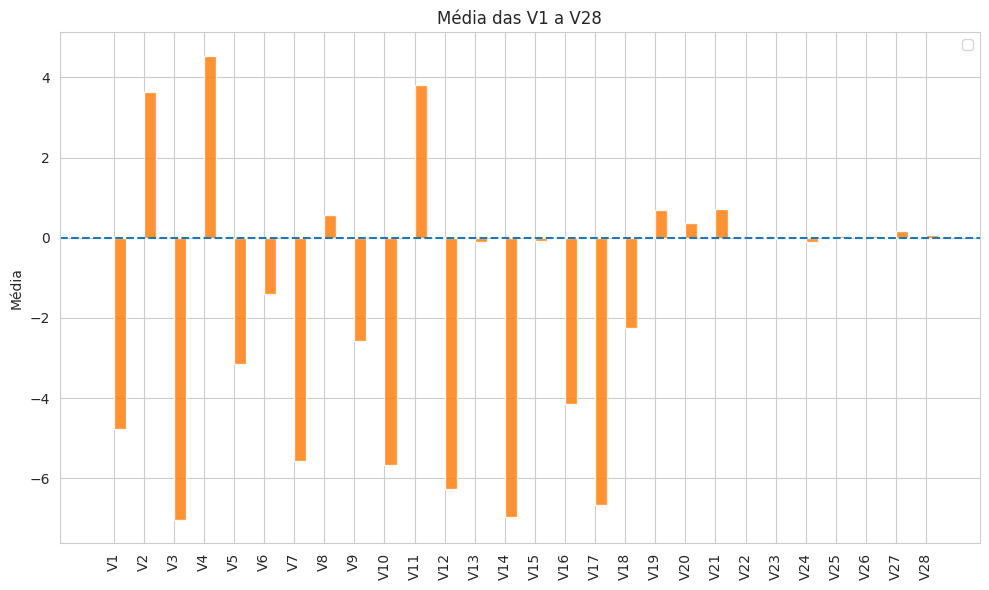

In [88]:
features_v = [f'V{i}' for i in range(1, 29)]

medias_leg = df[df['Class'] == 0][features_v].mean()
medias_fra = df[df['Class'] == 1][features_v].mean()

diff_abs = (medias_fra - medias_leg).abs().sort_values(ascending=False)

x = np.arange(len(features_v))
width = 0.4

plt.bar(x - width/2, medias_leg, width=width, alpha=0.85)
plt.bar(x + width/2, medias_fra, width=width, alpha=0.85)
plt.xticks(x, features_v, rotation=90)
plt.axhline(0, linestyle='--')
plt.title('Média das V1 a V28')
plt.ylabel('Média')
plt.legend()
plt.tight_layout()
plt.show()

### Parte 2 - Processamento dos dados

In [89]:
# Remover tempo
_df = df.drop(columns=['Time']).copy()

# Transformar valor
_df['Amount'] = np.log1p(_df['Amount'])
scaler = StandardScaler()
_df['Amount'] = scaler.fit_transform(_df[['Amount']])

display(_df.head())

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.124303,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-1.114639,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.682368,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.009339,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.670241,0


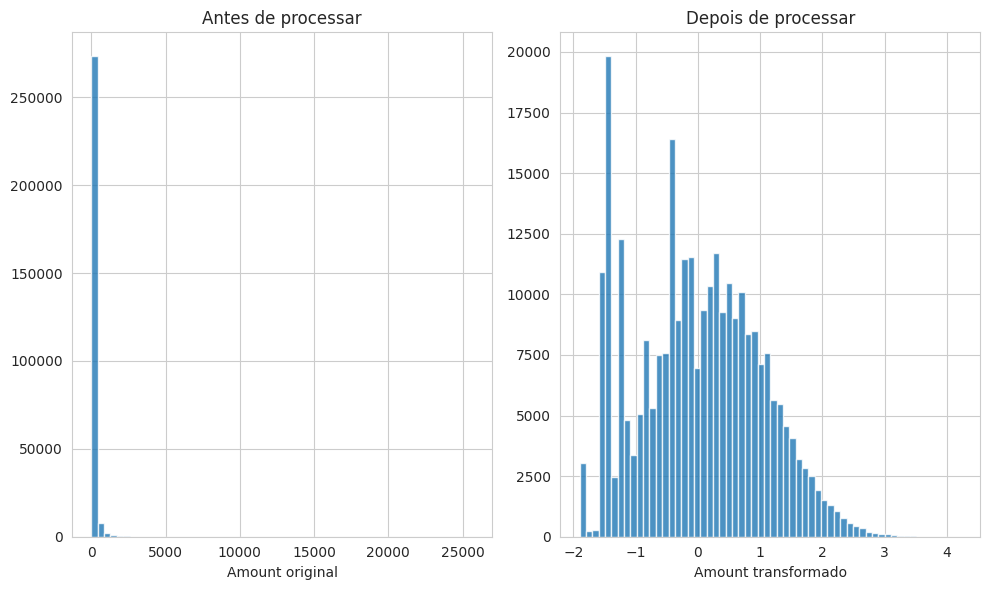

In [90]:
fig, axes = plt.subplots(1, 2)

axes[0].hist(df['Amount'], bins=60, alpha=0.8)
axes[0].set_title('Antes de processar')
axes[0].set_xlabel('Amount original')

axes[1].hist(_df['Amount'], bins=60, alpha=0.8)
axes[1].set_title('Depois de processar')
axes[1].set_xlabel('Amount transformado')

plt.tight_layout()
plt.show()

In [91]:

X = _df.drop(columns=['Class'])
y = _df['Class']

# Modificação: Dividindo em Treino, Validação e Teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print('Divisão dos dados:')
print(f'Treino:    {X_train.shape[0]:,} linhas')
print(f'Validação: {X_val.shape[0]:,} linhas')
print(f'Teste:     {X_test.shape[0]:,} linhas')
print(f'Fraudes no treino: {y_train.sum()} ({y_train.mean()*100:.4f}%)')
print(f'Fraudes na val:    {y_val.sum()} ({y_val.mean()*100:.4f}%)')
print(f'Fraudes no teste:  {y_test.sum()} ({y_test.mean()*100:.4f}%)')


Treino de teste
Treino: 227,845 linhas
Teste:  56,962 linhas
Fraudes no treino: 394 (0.1729%)
Fraudes no teste:  98 (0.1720%)


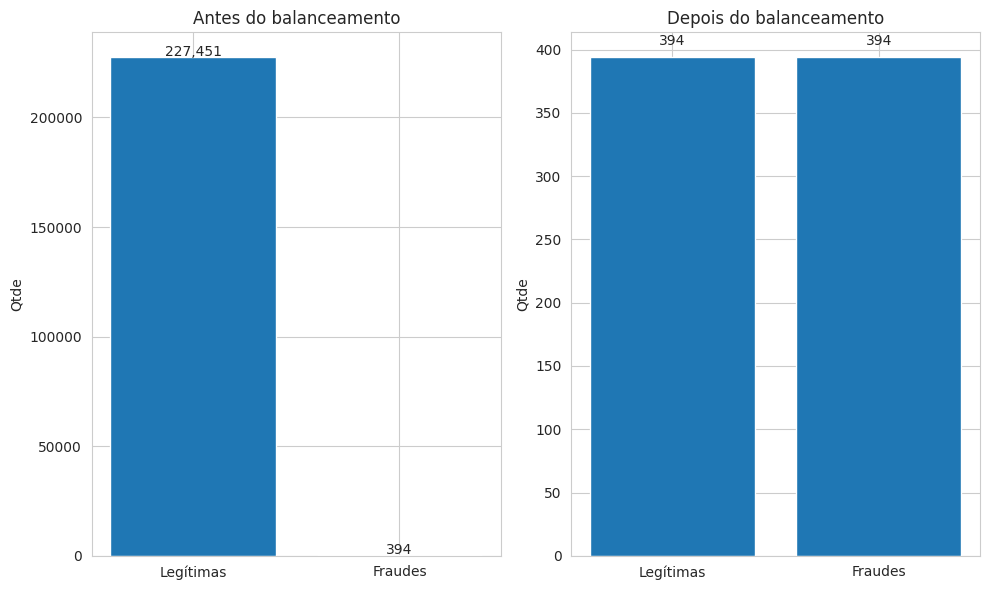

In [92]:
X_train_full = X_train.copy()
X_train_full['Class'] = y_train.values

fraudes_train   = X_train_full[X_train_full['Class'] == 1]
legitimas_train = X_train_full[X_train_full['Class'] == 0].sample(
    n=len(fraudes_train), random_state=42
)

df_bal = pd.concat([fraudes_train, legitimas_train]).sample(frac=1, random_state=42)

X_train_bal = df_bal.drop(columns=['Class'])
y_train_bal  = df_bal['Class']

antes  = y_train.value_counts().sort_index()
depois = y_train_bal.value_counts().sort_index()

fig, axes = plt.subplots(1, 2)

axes[0].bar(['Legítimas', 'Fraudes'], [antes[0], antes[1]])
axes[0].set_title('Antes do balanceamento')
axes[0].set_ylabel('Qtde')
for i, v in enumerate([antes[0], antes[1]]):
    axes[0].text(i, v + 500, f'{v:,}', ha='center')

axes[1].bar(['Legítimas', 'Fraudes'], [depois[0], depois[1]])
axes[1].set_title('Depois do balanceamento')
axes[1].set_ylabel('Qtde')
for i, v in enumerate([depois[0], depois[1]]):
    axes[1].text(i, v + 10, f'{v:,}', ha='center')

plt.tight_layout()
plt.show()

---

### Parte 3 - Modelar e avaliar

In [93]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42)
}

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'avg_prec': 'average_precision'
}

resultados_cv = {}

for nome, modelo in modelos.items():
    print(f'Treinando {nome}...')
    cv = cross_validate(modelo, X_train_bal, y_train_bal, cv=skf, scoring=scoring)
    resultados_cv[nome] = {metrica: cv[f'test_{metrica}'].mean() for metrica in scoring}
    print('Concluído!')

df_cv = pd.DataFrame(resultados_cv).T.rename(columns={
    'accuracy': 'Acurácia',
    'precision': 'Precisão',
    'recall': 'Recall',
    'f1': 'F1-Score',
    'roc_auc': 'AUC-ROC',
    'avg_prec': 'AUC-PR'
})

display(df_cv.round(4))

Treinando Logistic Regression...
Concluído!
Treinando Random Forest...
Concluído!
Treinando AdaBoost...
Concluído!


,Acurácia,Precisão,Recall,F1-Score,AUC-ROC,AUC-PR
Logistic Regression,0.9518,0.9787,0.9239,0.9500,0.9796,0.9855
Random Forest,0.9455,0.9783,0.9112,0.9432,0.9840,0.9877
AdaBoost,0.9480,0.9682,0.9265,0.9466,0.9814,0.9863


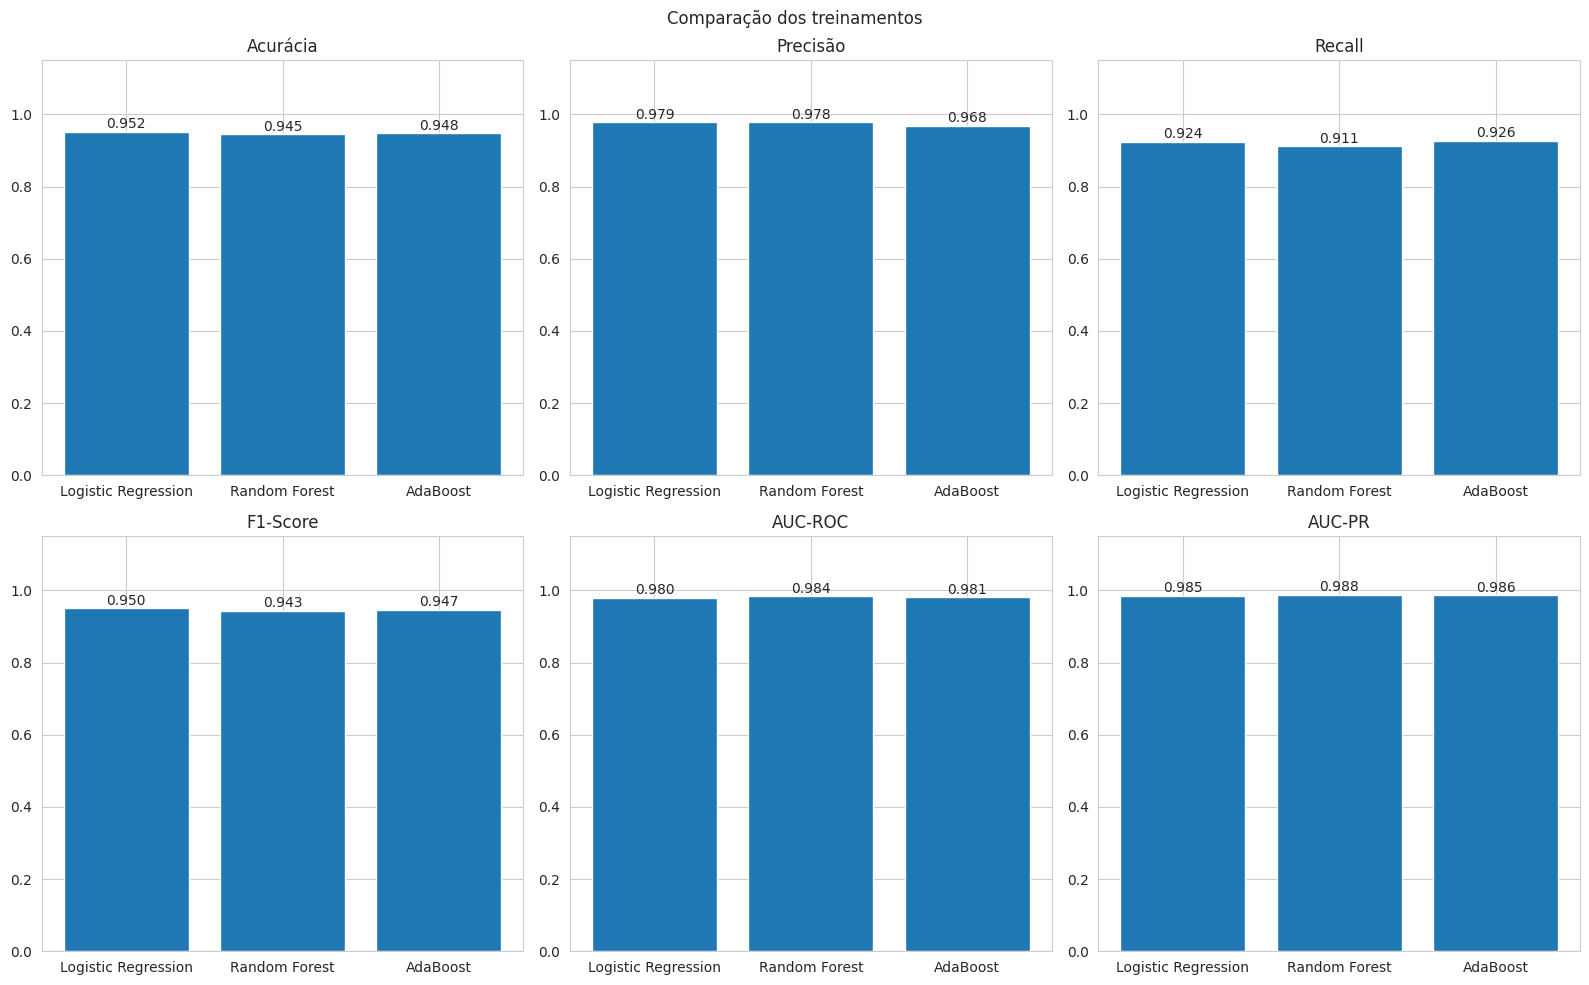

In [94]:
metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC', 'AUC-PR']
nomes_modelos = list(modelos.keys())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, metrica in enumerate(metricas):
    valores = df_cv[metrica].values
    bars = axes[i].bar(nomes_modelos, valores)
    axes[i].set_title(metrica)
    axes[i].set_ylim(0, 1.15)
    axes[i].tick_params(axis='x')
    for bar, val in zip(bars, valores):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center')

plt.suptitle('Comparação dos treinamentos')
plt.tight_layout()
plt.show()

### Passo 3.0: Tuning e Threshold na Validação
- Atendendo ao feedback: usando RandomizedSearchCV para o modelo Random Forest e usando o conjunto de validação para encontrar o threshold que maximiza o F1-Score sem contaminar o conjunto de teste.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# 1. TUNING DE HIPERPARÂMETROS
parametros = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5, 10]
}

tuning_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_distributions=parametros,
    n_iter=5,
    scoring='average_precision', # Corresponde à AUC-PR
    cv=5,
    random_state=42,
    n_jobs=-1
)
tuning_rf.fit(X_train_bal, y_train_bal)

melhor_rf = tuning_rf.best_estimator_
print("Melhores hiperparâmetros:", tuning_rf.best_params_)

# 2. DEFINIÇÃO DE THRESHOLD USANDO A BASE DE VALIDAÇÃO
# Previsões ocorrem apenas na base de validação!
probas_val = melhor_rf.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, probas_val)

# Busca do limiar que otimiza a F1-Score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
idx_otimo = np.argmax(f1_scores)
threshold_otimo = thresholds[idx_otimo]

print(f"Melhor Threshold (Baseado na Validação): {threshold_otimo:.4f}")


### Passo 3.0.1: Feature Importance
- Identificar as características mais determinantes para caracterizar fraude usando o melhor Random Forest.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

importancias = melhor_rf.feature_importances_
indices = np.argsort(importancias)[::-1]
nomes_features = X_train_bal.columns

plt.figure(figsize=(10, 8))
sns.barplot(x=importancias[indices], y=nomes_features[indices], palette='viridis')
plt.title('Feature Importance - Indicadores de Fraude')
plt.xlabel('Importância Relativa')
plt.ylabel('Features (PCA e Amount transformado)')
plt.tight_layout()
plt.show()


### Passo 3.1: Testes finais

In [95]:
resultados_teste = {}
modelos_treinados = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train_bal, y_train_bal)
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    modelos_treinados[nome] = (modelo, y_pred, y_proba)
    resultados_teste[nome] = {
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'AUC-PR': average_precision_score(y_test, y_proba)
    }

df_teste = pd.DataFrame(resultados_teste).T

display(df_teste.round(4))

,Acurácia,Precisão,Recall,F1-Score,AUC-ROC,AUC-PR
Logistic Regression,0.9582,0.0366,0.9184,0.0703,0.9762,0.6174
Random Forest,0.9663,0.0445,0.9082,0.0848,0.9760,0.6895
AdaBoost,0.9492,0.0303,0.9184,0.0586,0.9785,0.6508


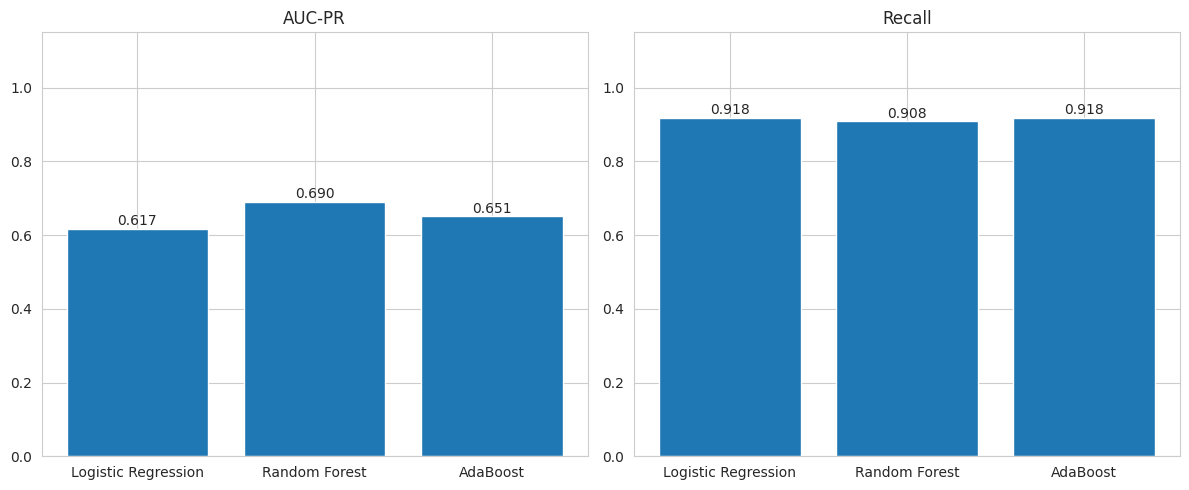

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metrica in zip(axes, ['AUC-PR', 'Recall']):
    valores = [resultados_teste[n][metrica] for n in resultados_teste]
    bars = ax.bar(list(resultados_teste.keys()), valores)
    ax.set_title(metrica)
    ax.set_ylim(0, 1.15)
    ax.tick_params(axis='x')
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

### Passo 3.2: Matriz de confusão

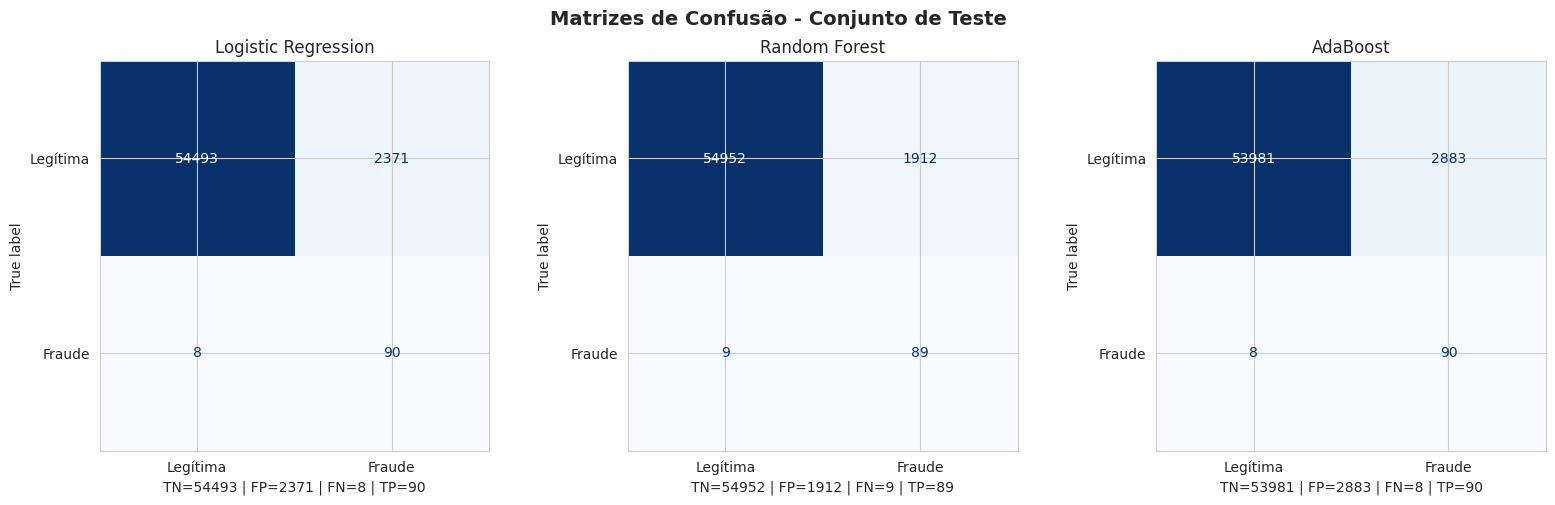

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, nome in zip(axes, modelos_treinados):
    _, y_pred, _ = modelos_treinados[nome]
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Legítima', 'Fraude']).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(nome)
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f'TN={tn} | FP={fp} | FN={fn} | TP={tp}')

plt.suptitle('Matrizes de Confusão - Conjunto de Teste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Passo 3.3: Curvar ROC

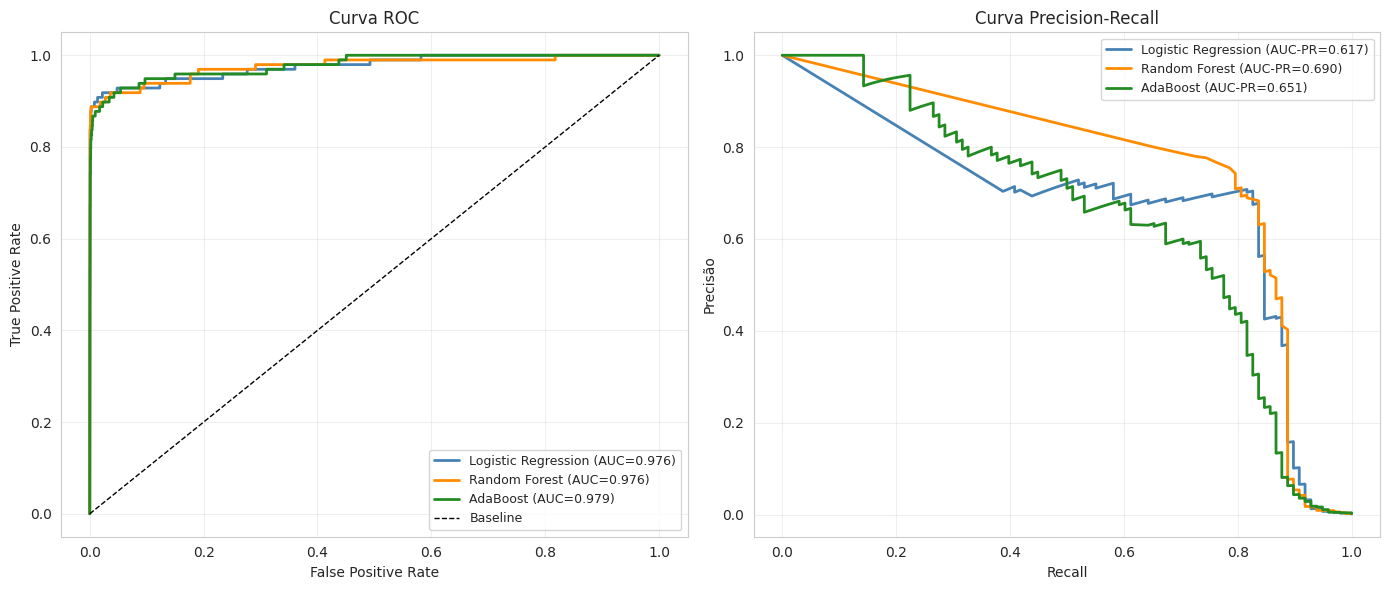

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cores_curvas = {
    'Logistic Regression': 'steelblue',
    'Random Forest': 'darkorange',
    'AdaBoost': 'forestgreen'
}

for nome, (_, _, y_proba) in modelos_treinados.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_roc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f'{nome} (AUC={auc_roc:.3f})', color=cores_curvas[nome], linewidth=2)

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    axes[1].plot(recall, precision, label=f'{nome} (AUC-PR={auc_pr:.3f})', color=cores_curvas[nome], linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Baseline')
axes[0].set_title('Curva ROC')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].set_title('Curva Precision-Recall')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisão')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Como o modelo fica se for fraude
# Quanto maior a AUC-PR, maior a chance do model achar fraudes

### Parte 4 - Análise comparativa e conclusão

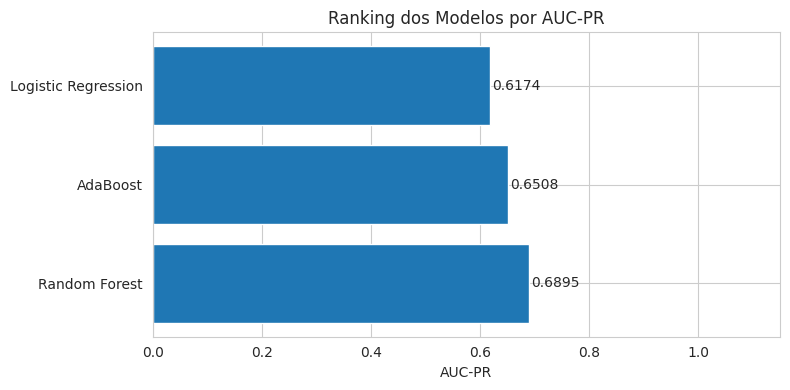

In [101]:
ordenados = sorted(resultados_teste, key=lambda nome: resultados_teste[nome]['AUC-PR'], reverse=True)
valores_aucpr = [resultados_teste[n]['AUC-PR'] for n in ordenados]

plt.figure(figsize=(8, 4))
bars = plt.barh(ordenados, valores_aucpr)
plt.title('Ranking dos Modelos por AUC-PR')
plt.xlabel('AUC-PR')
plt.xlim(0, 1.15)

for bar, v in zip(bars, valores_aucpr):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

In [102]:
melhor_nome = max(resultados_teste, key=lambda nome: resultados_teste[nome]['AUC-PR'])
_, _, y_proba_melhor = modelos_treinados[melhor_nome]
thresholds = np.arange(0.1, 0.9, 0.05)
recalls = []
precisoes = []
f1s = []

for t in thresholds:
    y_pred_t = (y_proba_melhor >= t).astype(int)
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    precisoes.append(precision_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

idx_otimo = int(np.argmax(f1s))
melhor_threshold = thresholds[idx_otimo]

print('Análise do limite do resultado')
print(f'Threshold por F1-Score: {melhor_threshold:.2f}')
print(f'Recall:   {recalls[idx_otimo]:.4f}')
print(f'Precisão: {precisoes[idx_otimo]:.4f}')
print(f'F1:       {f1s[idx_otimo]:.4f}')

Análise do limite do resultado
Threshold por F1-Score: 0.85
Recall:   0.8776
Precisão: 0.4725
F1:       0.6143


### Conclusão (restante no relatório)
- O dataset é extremamente desbalanceado, então acurácia
isolada não resolve o problema
- A transformação do valor e o uso de stratify melhoram a resultado final.
- O under-sampling foi aplicado corretamente apenas no treino, igualando as classes sem contaminar o teste
- O melhor modelo final foi: Random Forest (o que melhor apresentou resultado apesar da variância)
- A métrica principal para defender a escolha do modelo é a AUC-PR
- O threshold ótimo encontrado foi: 0.85 (podendo ser ajustado conforme o custo do erro para a empresa.)
